In [1]:
import jsonlines
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jsonlines
from cattrs import unstructure
from dataclasses import dataclass, field
from itertools import combinations

from scheduler.entities import RunningTask, Task, Node, Edge, NetworkTopology
from scheduler.load_info import load_nodes, load_edges, load_tasks, build_task_graph

# Generating Synthetic Data

Experimenting with creating synthetic metrics for assigned tasks. Basically, generating somewhat plausible time series for CPU, memory, etc (simulate running jobs on a cluster).

0.13831199165325153 0.01093584607400225 2533.664345390965


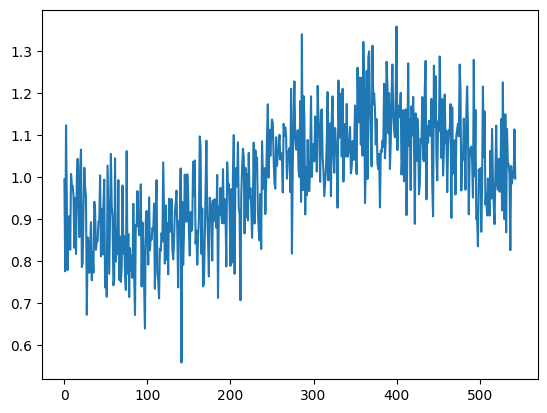

In [30]:
rng = np.random.default_rng()

size = 544

period = rng.uniform(0, 10 * size)
a = rng.uniform(0.05, 0.95)
b = 2 * np.pi / period
c = rng.uniform(0, 10 * size)

print(a, b, c)

scale_factor = 1 + a * np.sin( b * (np.arange(size) - c) )
noise = rng.normal(loc=0, scale=0.1, size=size)

cpu = scale_factor + noise

plt.plot(cpu)

# Fake Network Control Data

Experimenting with generating different aspects of army control demo data (network topo, nodes, task requests, etc).

## Exploring Current Data

Just seeing what the network topo in the CSV looks like.

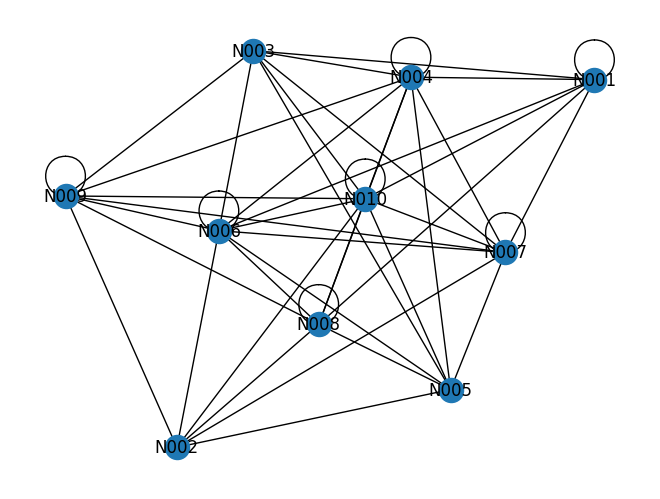

In [30]:
node_path = "dummy_data/nodes.csv"
edge_path = "dummy_data/edges.csv"
nodes = load_nodes(node_path)
edges = load_edges(edge_path)
network = NetworkTopology(nodes.values(), edges.values())
nx.draw(network._graph, with_labels=True)

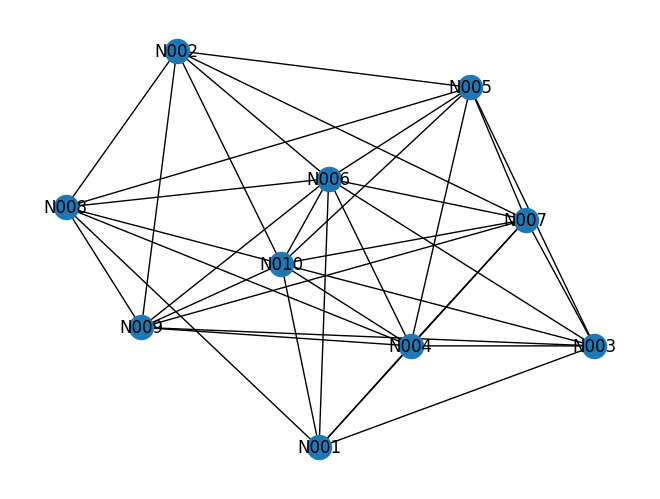

In [46]:
res = nx.Graph()
for n in network._graph.nodes:
    res.add_node(n)
for n1, n2 in combinations(res.nodes, 2):
    path = nx.shortest_path(network._graph, n1, n2)
    nx.add_path(res, path)
nx.draw(res, with_labels=True)

## Generate Fake Network Topo

Generate a fake compute cluster, with node and link information.

31.0


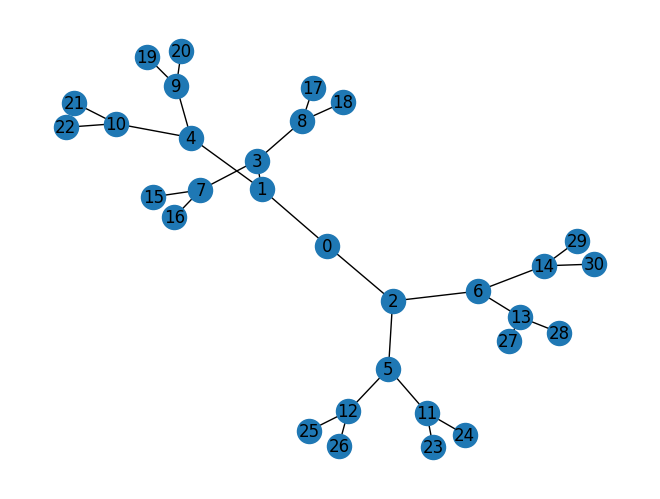

In [3]:
# Generate basic topology for network. Sparse to mimic edge network.
r = 2
h = 4
num_nodes = (r ** (h + 1) - 1) / (r - 1)
print(num_nodes)

graph = nx.balanced_tree(r, h)
nx.draw(graph, with_labels=True)

In [4]:
# Generate node specs.
import random

# Each node can be one of 4 tiers of CPU + memory.
cpu_options = [2, 4, 8, 16]
memory_options = [8, 16, 32, 64]

cpu_specs = random.choices(cpu_options, weights=reversed(cpu_options), k=len(graph.nodes))
mem_specs = [4 * cpu for cpu in cpu_specs]

gen_nodes = []
for i, (cpu, memory) in enumerate(zip(cpu_specs, mem_specs)):
    n_id = f'N{i:03}'
    node = Node(node_id=n_id, cpu_capacity=cpu, memory_capacity=memory)
    gen_nodes.append(node)
    print(node)

Node(node_id='N000', cpu_capacity=8, memory_capacity=32, used_cpu=0.0, used_memory=0.0)
Node(node_id='N001', cpu_capacity=8, memory_capacity=32, used_cpu=0.0, used_memory=0.0)
Node(node_id='N002', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N003', cpu_capacity=16, memory_capacity=64, used_cpu=0.0, used_memory=0.0)
Node(node_id='N004', cpu_capacity=8, memory_capacity=32, used_cpu=0.0, used_memory=0.0)
Node(node_id='N005', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N006', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N007', cpu_capacity=4, memory_capacity=16, used_cpu=0.0, used_memory=0.0)
Node(node_id='N008', cpu_capacity=4, memory_capacity=16, used_cpu=0.0, used_memory=0.0)
Node(node_id='N009', cpu_capacity=4, memory_capacity=16, used_cpu=0.0, used_memory=0.0)
Node(node_id='N010', cpu_capacity=2, memory_capacity=8, used_cpu=0.0, used_memory=0.0)
Node(node_id='N011', cpu_capacity=2

In [5]:
# Generate edges.
bandwidth = 100 # Set to fixed mbps for now.

gen_edges = []
for u, v in graph.edges:
    u_id = f'N{u:03}'
    v_id = f'N{v:03}'
    edge = Edge(edge_id=(u_id, v_id), capacity=bandwidth)
    gen_edges.append(edge)
    print(edge)

Edge(edge_id=('N000', 'N001'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N000', 'N002'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N003'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N001', 'N004'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N005'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N002', 'N006'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N007'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N003', 'N008'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N009'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N004', 'N010'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N011'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N005', 'N012'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N013'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N006', 'N014'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N015'), capacity=100, used_bandwidth=0.0)
Edge(edge_id=('N007', 'N0

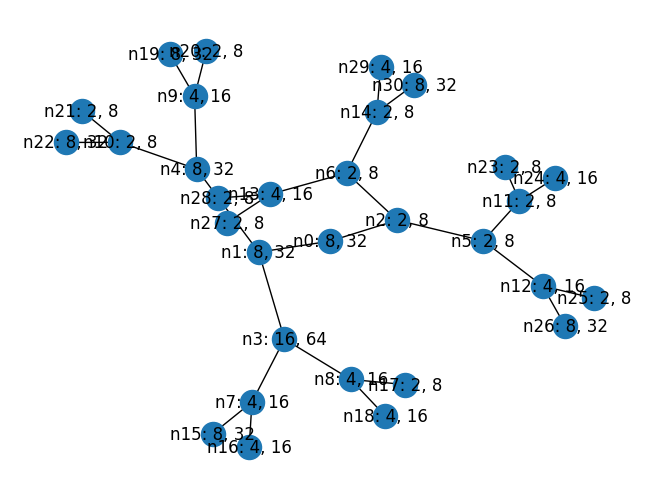

In [6]:
# View generated topo with associated CPU/memory count.
gen_graph = graph.copy(as_view=False)
nx.set_node_attributes(gen_graph, {i: node for i, node in enumerate(gen_nodes)}, 'data')
labels = {i: f'n{i}: {node.cpu_capacity}, {node.memory_capacity}' for i, node in enumerate(gen_nodes)}
nx.draw(gen_graph, with_labels=True, labels=labels)

## Generating Task Information

Tasks can either be independent, or have communication dependencies between each other, so we must generate various task "graphs".

Num Tasks: 62


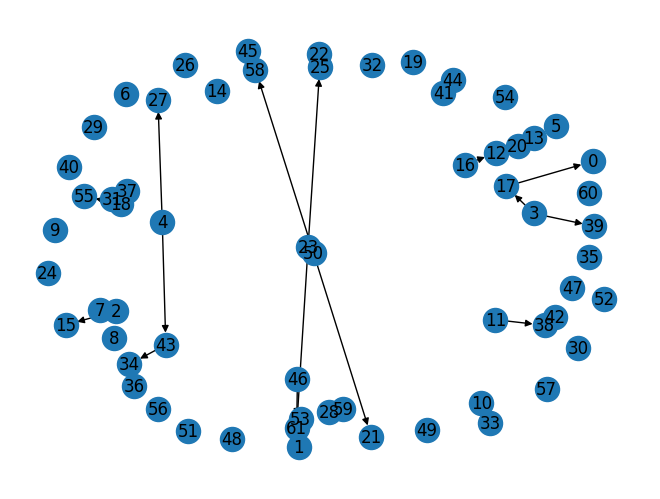

In [15]:
# Generate task graphs.
num_tasks = int(num_nodes * 2)
print(f'Num Tasks: {num_tasks}')
# Number of edges should scale linearly with nodes -> maintains sparsity.
frac = (num_tasks / num_tasks ** 2) / 2
task_graph = nx.fast_gnp_random_graph(num_tasks, p=frac, directed=True)
nx.draw(task_graph, with_labels=True)

In [72]:
# Visualize different task graphs.
comps = list(nx.weakly_connected_components(task_graph))
num_comps = 0
for comp in comps:
    num_comps += 1
    print(comp)
num_comps

{0, 17, 3, 39}
{1, 46, 53, 22, 23, 25, 61}
{2, 7, 15}
{43, 34, 27, 4}
{5, 12, 13, 16, 20}
{6}
{8}
{9}
{10}
{42, 11, 38}
{14}
{18, 31, 37, 55}
{19}
{50, 45, 58, 21}
{24}
{26}
{59, 28}
{29}
{30}
{32}
{33}
{35}
{36}
{40}
{41, 44}
{47}
{48}
{49}
{51}
{52}
{54}
{56}
{57}
{60}


34

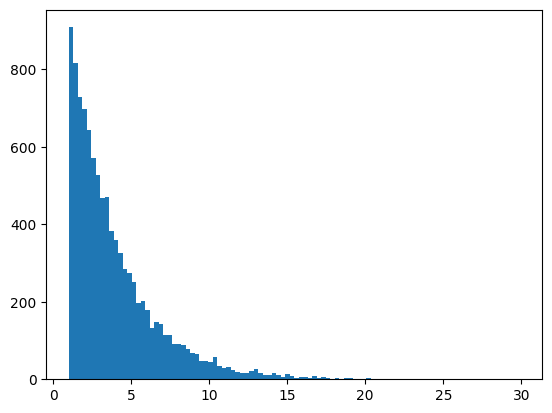

In [70]:
rng = np.random.default_rng()
plt.hist(rng.exponential(3, 10000) + 1, bins=100)
plt.show()

In [ ]:
import time


def make_peer_bws(graph: nx.DiGraph, node: int):
    peer_bws = {}
    rng = np.random.default_rng()
    for n in graph.neighbors(node):
        peer_id = f'T{n:03}'
        peer_bws[peer_id] = np.clip(rng.exponential(3) + 1, 1, 100)
    return peer_bws


def process_comp(task_graph: nx.DiGraph, comp: list[int], arrival_time: int = 0, stdev=1) -> list[Task]:
    rng = np.random.default_rng()
    tasks = []
    for v in comp:
        task_id = f'T{v:03}'
        
        cpu = np.clip(rng.rayleigh(4), 0, 16)
        memory = np.clip(rng.rayleigh(16), 0, 64)
        offset = max(0, rng.normal(loc=arrival_time, scale=stdev))
        peer_bws = make_peer_bws(task_graph, v)
        duration = rng.uniform(3 * 60, 15 * 60)
                                 
        task = Task(
            task_id=task_id,
            arrival_offset_s=offset,
            initial_cpu=cpu,
            initial_memory=memory,
            peer_bandwidths=peer_bws,
            duration_s=duration
        )
        tasks.append(task)
    return tasks

In [73]:
# Generate task specs for task graph.
interval = 30
rng = np.random.default_rng()

tasks = []
comp_idx = []
curr_time = 0
for i, comp in enumerate(comps):
    curr_time += rng.uniform(0, 2 * interval)
    out = process_comp(task_graph, comp, arrival_time=curr_time, stdev=interval / 2)
    tasks += out
    comp_idx += [i] * len(out)
    print(f'COMP {i}:\n')
    for task in out:
        print(task)
    print()

COMP 0:

Task(task_id='T000', arrival_offset_s=46.31157051206405, duration_s=604.7017141994288, initial_cpu=np.float64(6.44529479761345), initial_memory=np.float64(33.29229506014816), peer_bandwidths={})
Task(task_id='T017', arrival_offset_s=81.707360839523, duration_s=776.349551038868, initial_cpu=np.float64(4.884096584105642), initial_memory=np.float64(11.506057237871854), peer_bandwidths={'T000': np.float64(3.386921142782755)})
Task(task_id='T003', arrival_offset_s=76.49782762540703, duration_s=306.91996152261174, initial_cpu=np.float64(3.0328555958489525), initial_memory=np.float64(6.6944922030388145), peer_bandwidths={'T017': np.float64(4.0799305609464085), 'T039': np.float64(2.0655203886754965)})
Task(task_id='T039', arrival_offset_s=84.45055281424814, duration_s=552.0955408966379, initial_cpu=np.float64(5.618723858756789), initial_memory=np.float64(24.678553501464172), peer_bandwidths={})

COMP 1:

Task(task_id='T001', arrival_offset_s=92.18787986056648, duration_s=525.334531436

In [74]:
# Visualize arrival times for different tasks in the format: task id, task graph (component) idx, arrival time offset (s)
for comp_i, t in sorted(zip(comp_idx, tasks), key=lambda x: x[1].arrival_offset_s):
    print(t.task_id, comp_i, t.arrival_offset_s)

T000 0 46.31157051206405
T046 1 46.911992362113324
T023 1 48.00370265775224
T061 1 63.544852162257605
T022 1 68.02205423804352
T007 2 68.03319511775537
T053 1 73.0248785972546
T003 0 76.49782762540703
T015 2 79.18360559235592
T017 0 81.707360839523
T039 0 84.45055281424814
T002 2 84.78239205475123
T001 1 92.18787986056648
T025 1 106.5319361430767
T043 3 120.23943997662752
T027 3 132.58486814508498
T034 3 134.2549549010832
T004 3 137.71567710064687
T006 5 168.0136476150283
T005 4 169.35634496618886
T020 4 181.43538595655747
T012 4 183.48898941347883
T013 4 190.35343404989618
T008 6 196.49105545376517
T016 4 200.97611415745328
T009 7 284.4032552587152
T010 8 348.17857697287053
T038 9 369.2693748286234
T042 9 371.436771824877
T011 9 375.96241944259725
T014 10 420.66929103543214
T031 11 426.0922494490154
T018 11 434.6804267582757
T037 11 441.9266082430871
T055 11 448.66965929734977
T019 12 449.738111003123
T058 13 455.4440538362896
T050 13 490.9696841938792
T028 16 495.386947663186
T045 13

## Serialize Data

Save as JSONL so we can have nested data structures.

In [2]:
def serialize_jsonl(data: list, path: str):
    with jsonlines.open(path, 'w') as writer:
        if data:
            data_type = type(data[0])
            data = unstructure(data, list[data_type])
            writer.write_all(data)

In [75]:
task_gen_path = 'tasks.jsonl'
sorted_data = sorted(tasks, key=lambda x: x.arrival_offset_s)
serialize_jsonl(sorted_data, task_gen_path)

In [66]:
node_gen_path = 'nodes.jsonl'
serialize_jsonl(gen_nodes, node_gen_path)

In [67]:
edge_gen_path = 'edges.jsonl'
serialize_jsonl(gen_edges, edge_gen_path)